### Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data

In [11]:
data = pd.read_csv('data_engineer/data_clean_interpolasi.csv')
data

,date,komoditas,provinsi,harga
0,2021-02-18,Beras Medium,Jawa Timur,10600.000000
1,2021-02-19,Beras Medium,Jawa Timur,10594.736842
2,2021-02-20,Beras Medium,Jawa Timur,10589.473684
3,2021-02-21,Beras Medium,Jawa Timur,10584.210526
4,2021-02-22,Beras Medium,Jawa Timur,10578.947368
...,...,...,...,...
37507,2025-06-15,Minyak Goreng Kemasan,Jawa Tengah,19746.000000
37508,2025-06-16,Minyak Goreng Kemasan,Jawa Tengah,19690.000000
37509,2025-06-14,Minyak Goreng Kemasan,Jawa Timur,19882.000000
37510,2025-06-15,Minyak Goreng Kemasan,Jawa Timur,19752.000000


In [16]:
data.columns

Index(['date', 'komoditas', 'provinsi', 'harga'], dtype='object')

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37512 entries, 0 to 37511
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       37512 non-null  object 
 1   komoditas  37512 non-null  object 
 2   provinsi   37512 non-null  object 
 3   harga      37512 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.1+ MB


- Dataset ini terdapat 37512 baris dan memiliki 4 kolom
- Terdapat 3 type object (date, komoditas dan provinsi) dan 1 type float untuk harga

In [13]:
data.isnull().sum()

date         0
komoditas    0
provinsi     0
harga        0
dtype: int64

Dataset ini tidak memiliki missing value

In [14]:
data.duplicated().sum()

0

Dataset ini tidak memiliki data duplikat

In [19]:
data['date'] = pd.to_datetime(data['date'])

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37512 entries, 0 to 37511
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       37512 non-null  datetime64[ns]
 1   komoditas  37512 non-null  object        
 2   provinsi   37512 non-null  object        
 3   harga      37512 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 1.1+ MB


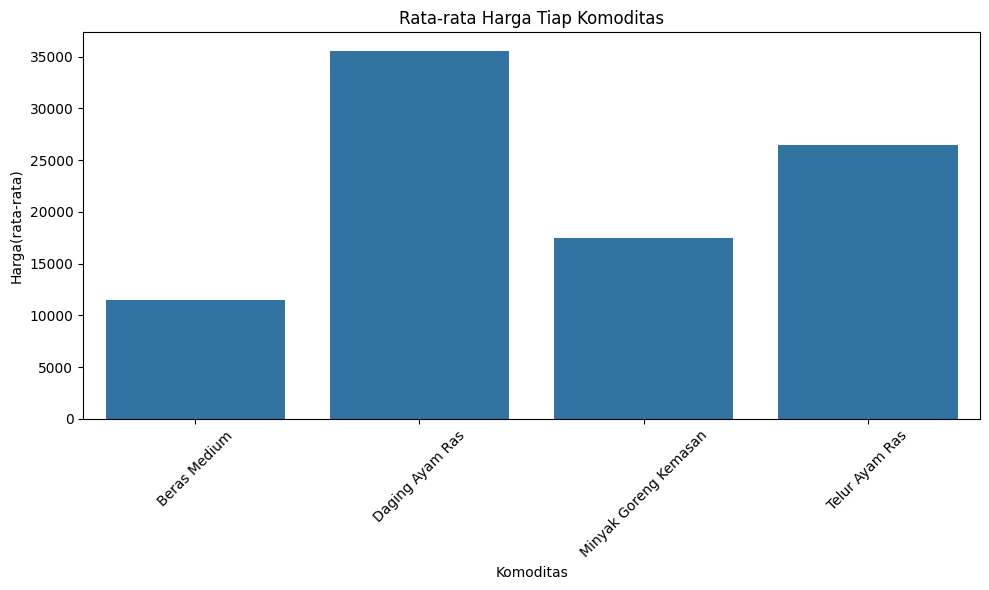

In [18]:
avg_harga = data.groupby('komoditas')['harga'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=avg_harga, x='komoditas', y='harga')

plt.title('Rata-rata Harga Tiap Komoditas')
plt.xlabel('Komoditas')
plt.ylabel('Harga(rata-rata)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Dari dataset ini untuk :
- Rata-rata harga Daging ayam ras yaitu Rp. 35,582
- Rata-rata harga beras medium yaitu Rp. 11,511
- Rata-rata harga minyak goreng kemasan Rp. 17,456
- Rata-rata harga Telur Ayam Ras Rp. 26,476 
<br>Insight
1. Daging Ayam Ras adalah komoditas dengan harga tertinggi <br>
Rata-rata harga daging ayam ras mencapai Rp35.582, menunjukkan bahwa komoditas ini memiliki nilai ekonomis yang paling tinggi di antara komoditas lainnya. Hal ini bisa disebabkan oleh biaya produksi dan distribusi yang lebih besar dibandingkan komoditas lain seperti beras atau telur.

2. Beras Medium menjadi komoditas dengan harga terendah <br>
Rata-rata harga beras medium hanya Rp11.511, yang menandakan bahwa beras, sebagai kebutuhan pokok masyarakat, relatif lebih stabil dan terjangkau. Hal ini juga bisa mencerminkan adanya subsidi atau kontrol harga dari pemerintah.

3. Minyak Goreng Kemasan memiliki harga menengah <br>
Dengan rata-rata harga Rp17.456, minyak goreng berada di tengah-tengah dalam segi harga. Produk ini sering mengalami fluktuasi harga tergantung pada pasokan bahan baku seperti kelapa sawit dan kondisi pasar global.

4. Telur Ayam Ras menunjukkan harga yang kompetitif <br>
Telur ayam ras memiliki rata-rata harga Rp26.476, menjadikannya sumber protein yang cukup terjangkau. Telur sering dijadikan alternatif daging karena lebih murah dan mudah didistribusikan.<

#### Tren Rata-rata Harga

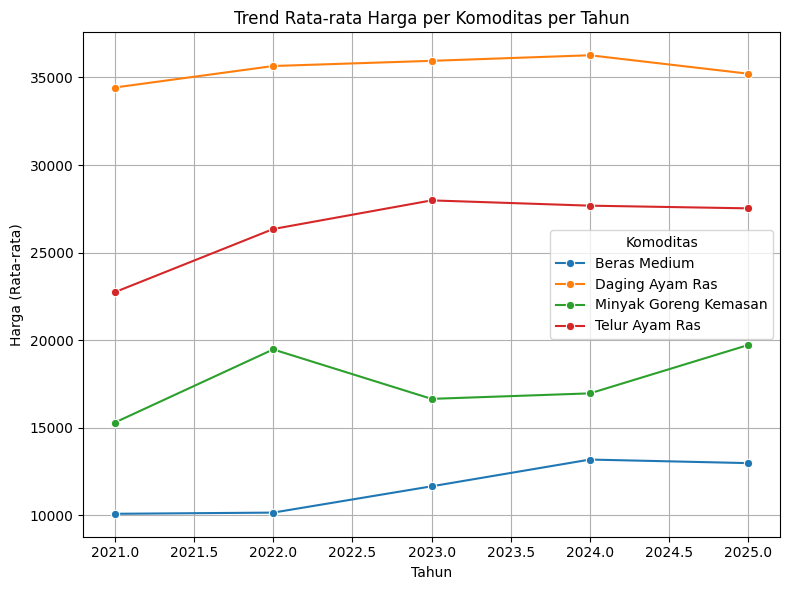

In [45]:
data['year'] = data['date'].dt.year
avg_per_year_komoditas = data.groupby(['year', 'komoditas'])['harga'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.lineplot(data=avg_per_year_komoditas, x='year', y='harga', hue='komoditas', marker='o')

plt.title('Trend Rata-rata Harga per Komoditas per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Harga (Rata-rata)')
plt.legend(title='Komoditas')
plt.grid(True)
plt.tight_layout()
plt.show()

Berdasrkan tren diatas:
1. Daging Ayam Ras : Harga terus naik dari 2021 hingga puncak di 2024 (sekitar Rp 36.700), Turun ringan di 2025, tapi tetap lebih tinggi dibanding tahun 2021 ini kemungkinan disebabkan Naiknya biaya pakan dan produksi dan Stabilnya permintaan masyarakat
2. Telur Ayam Ras : Harga naik stabil dari 2021 hingga 2023, mencapai sekitar Rp 28.000. Mulai sedikit menurun pada 2024 dan 2025, namun tetap lebih tinggi dari 2021 ini bisa disebabkan pengaruh keseimbangan antara pasokan dan permintaan
3.  Minyak Goreng Kemasan : Lonjakan besar dari 2021 ke 2022, dari Rp 15.000-an ke Rp 19.500. Turun di 2023 dan 2024, lalu naik lagi di 2025, Menunjukkan dampak krisis minyak goreng global & lokal, lalu mulai pulih
4. Beras Medium : Kenaikan konsisten dari 2021 ke 2024, dari sekitar Rp 10.000 ke Rp 13.200. Penurunan sedikit di 2025, tapi tetap di atas harga tahun-tahun awal Menunjukkan adanya tekanan inflasi ringan dan potensi kenaikan biaya produksi atau distribusi. Namun, stabilitas tetap terjaga karena fluktuasinya tidak ekstrem

#### Tren rata-rata harga perbulan

In [39]:
def tren_per_month(tahun):
    data_2023 = data[data['date'].dt.year == tahun].copy()

    # Tambahkan kolom bulan
    data_2023['month'] = data_2023['date'].dt.month
    avg_per_month_komoditas = data_2023.groupby(['month', 'komoditas'])['harga'].mean().reset_index()

    plt.figure(figsize=(8, 6))
    sns.lineplot(data=avg_per_month_komoditas, x='month', y='harga', hue='komoditas', marker='o')

    plt.title(f'Trend Rata-rata Harga per Komoditas per Bulan {tahun}')
    plt.xlabel('Tahun')
    plt.ylabel('Harga (Rata-rata)')
    plt.legend(title='Komoditas')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

##### Tren rata-rata harga di tahun 2021

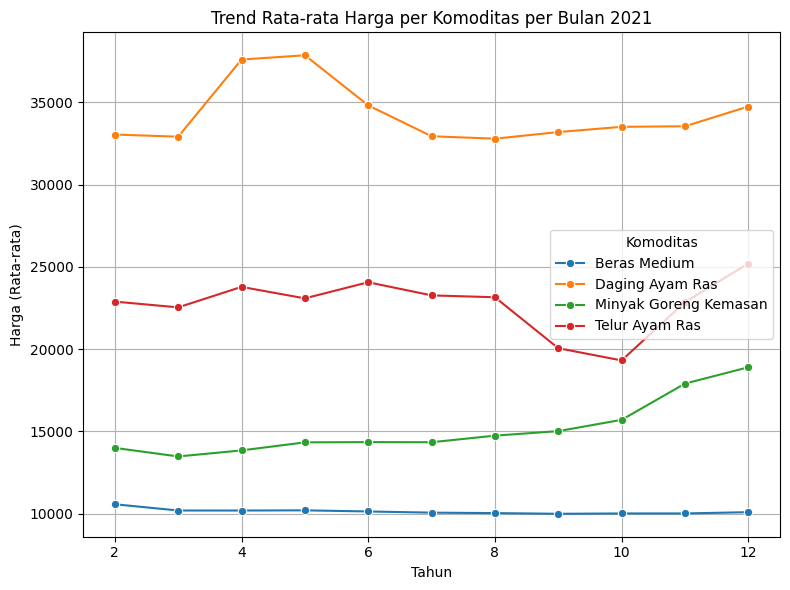

In [40]:
tren_per_month(2021)

Dari diagram tren diatas:
1. Daging Ayam Ras : Terjadi kenaikan signifikan pada April–Mei (puncak di Mei sekitar Rp 38.000), Setelah itu harga turun drastis hingga Juli, lalu relatif stabil sisa tahun Pola ini mencerminkan lonjakan konsumsi menjelang Idul Fitri (Mei) lalu penurunan pasca Lebaran.
2. Telur ayam ras : Harga cenderung stabil di kisaran Rp 23.000–Rp 24.000 hingga bulan Juli, Penurunan tajam terjadi pada Agustus–Oktober (turun hingga Rp 19.000), lalu rebound pada Desember, penirinan ini bisa disebabkan Surplus pasokan atau Penurunan permintaan pasca libur besar
3. Minyak Goreng Kemasan : Harga relatif stabil di bawah Rp 15.000 hingga bulan September, Lonjakan drastis terjadi pada Oktober–Desember, hingga menyentuh hampir Rp 19.000 di akhir tahun, ini kemungkinan disebabkan Krisis minyak goreng nasional/global tahun 2021, akibat harga CPO naik
4. Beras Medium : Harga paling stabil sepanjang tahun berkisar Rp 10.000–Rp 10.500 Hampir tidak menunjukkan perubahan berarti ini kemungkinan disebabkan Peran pemerintah dalam menjaga harga beras melalui cadangan dan subsidi.

##### Tren rata-rata harga di tahun 2022

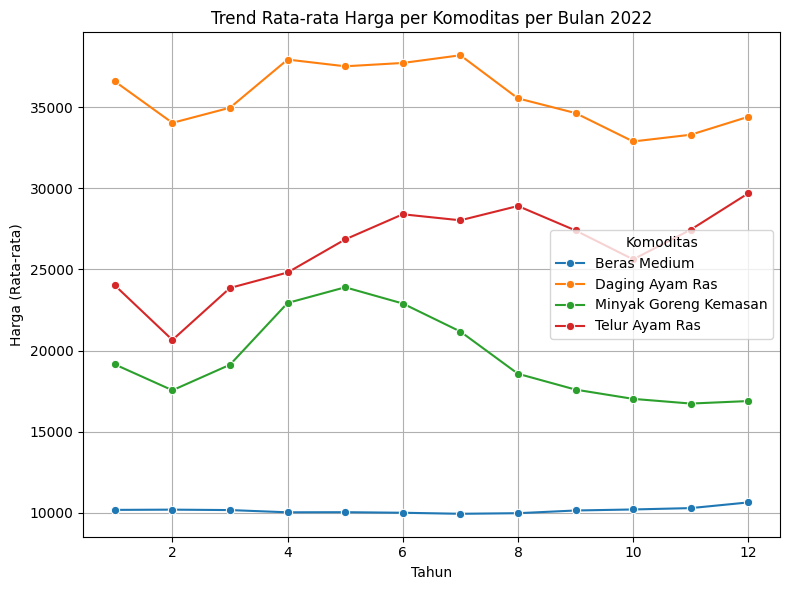

In [41]:
tren_per_month(2022)

Dari dataset di atas:
1. Daging Ayam Ras : Harga cukup tinggi dan fluktuatif sepanjang tahun, Terjadi lonjakan tertinggi pada bulan Juli, mencapai puncak sekitar Rp 37.500. Kenaikan ini bisa disebabkan oleh Kenaikan biaya produksi (pakan, DOC), momen hari besar keagamaan yaitu idul adha dan Ketidakseimbangan pasokan dan permintaan.
2. Telur Ayam Ras : Harga naik konsisten dari bulan Maret ke Juli, tertinggi di bulan Agustus, kemudian sedikit menurun sebelum naik lagi di Desember. Pola ini menunjukkan permintaan meningkat menjelang semester kedua, mungkin karena Kebutuhan rumah tangga dan industri makanan, tahun ajaran baru (konsumsi kantin/sekolah) dan Pengaruh inflasi umum
3. Minyak Goreng Kemasan : Harga puncak terjadi di bulan Mei (Rp 24.000), lalu turun bertahap hingga akhir tahun. Ini mencerminkan kebijakan pemerintah yang sempat mencabut lalu mengembalikan subsidi atau HET (Harga Eceran Tertinggi) pada periode tersebut
4. Beras Medium : Paling stabil sepanjang tahun, berkisar di Rp 10.000–10.500, Ada sedikit penurunan di pertengahan tahun, lalu kembali naik di akhir tahun. Stabilitas ini menunjukkan bahwa beras lebih tahan terhadap fluktuasi musiman, kemungkinan karena Cadangan pemerintah cukup kuat dan Panen relatif terkontrol.


##### Tren rata-rata harga di tahun 2023

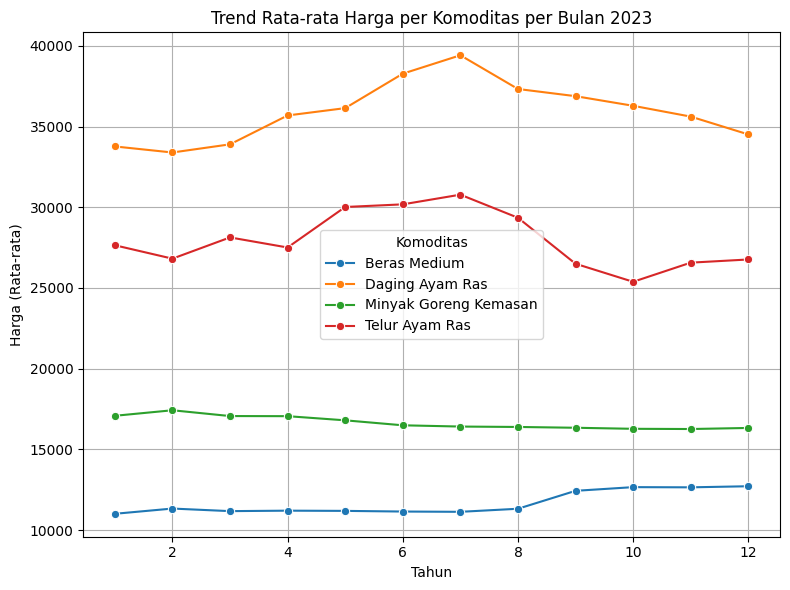

In [42]:
tren_per_month(2023)

Dari trend diatas :
1. Harga daging ayam ras : Harga tertinggi ada di bulan july yaitu mencapai harga sekitar 39,000. Menurut Ketua Umum Gabungan Organisasi Peternak Ayam Nasional (Gopan), Herry Darmawan, salah satu faktor penyebab kenaikan harga daging ayam terletak pada sisi hulu, yakni terjadinya kenaikan harga pakan ayam
2. Telur Ayam Ras : Mengalami kenaikan harga signifikan pada Mei–Juli, dengan puncak di bulan Juli (Rp 31.000), setelah itu, harga turun tajam hingga Oktober, lalu stabil di kisaran Rp 26.000–27.000. Kenaikan ini menurut satgas pangan polri yaitu salah satunya karena kelangkaan bahan baku pakan ternak khususnya jagung, dan peningkatan permintaan telur untuk program bantuan sosial.
3. Minyak Goreng Kemasan: Cenderung stabil sepanjang tahun, sedikit turun dari Rp 17.500 ke sekitar Rp 16.300 ini disebabkan Pemerintah melakukan intervensi melalui kebijakan Domestic Market Obligation (DMO) untuk memastikan pasokan minyak goreng dalam negeri terpenuhi dan stabil. Selain itu, harga minyak sawit mentah (CPO) dunia yang menjadi bahan baku utama juga relatif stabil pada periode ini. 
4. Beras Medium : Dari bulan januari - agustus harga beras medium relatif stabil dan ada kenaikan di bulan september menjadi sekitar 17,000 kenaikan ini bisa disebakan oleh gagal panen lokal atau kekeringan dan dampak inflasi dan kenaikan harga pupuk 

##### Tren rata-rata harga di tahun 2024

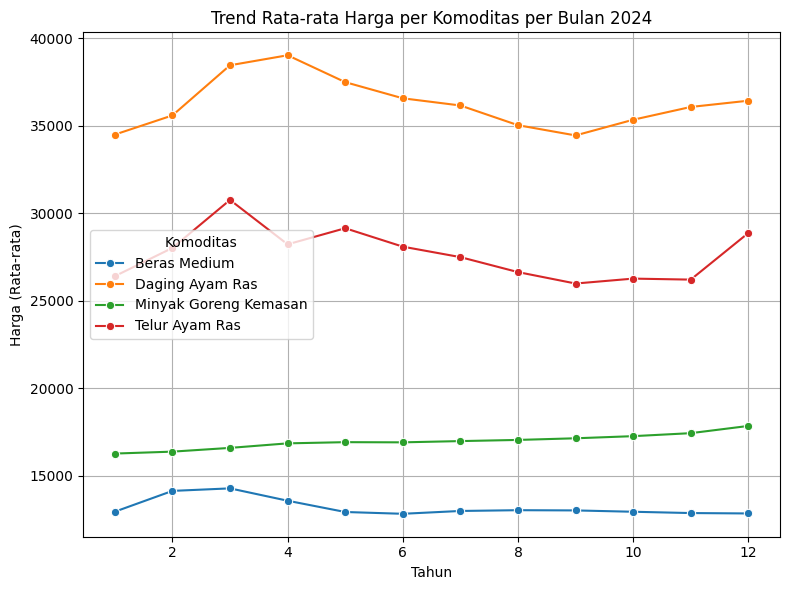

In [43]:
tren_per_month(2024)

Dari diagram diatas :
1. Daging Ayam Ras : Harga meningkat tajam dari Januari (Rp 34.500) ke Maret (Rp 39.000), kemudian harga menurun bertahap hingga September. Harga naik tajam di bulan januari - maret itu kemungkinan disebabkan karena bulan ramadhan di bulan Maret dan penyebab menurun setelah maret bisa disebabkan Penurunan daya beli masyarakat setelah Lebaran,oversupply (pasokan berlebihan), dan harga pakan yang stabil atau menurun
2. Telur Ayam Ras : Puncak harga di Maret (Rp 31.000), sejalan dengan puncak daging ayam ini bisa di sebabkan karena di bulan ini berbarengan dengan bulang puasa
3. Minyak Goreng Kemasan : Tren naik perlahan namun konsisten dari Januari ke Desember, harga dari Rp 16.300 naik ke Rp 17.900 ini disebabkan kenaikan harga minyak sawit mentah (CPO) sebagai bahan baku utama, yang dipengaruhi oleh fluktuasi harga minyak dunia dan permintaan global.
4.  Beras Medium : Peningkatan awal tahun (Januari–Maret) dari Rp 13.000 ke Rp 14.300, lalu turun kembali dan stabil di kisaran Rp 12.900–13.000, lonjakan awal bisa disebabkan oleh Permintaan tinggi menjelang Ramadhan dan Gangguan distribusi awal tahun (cuaca, panen belum tiba)

##### Tren rata-rata harga di tahun 2025

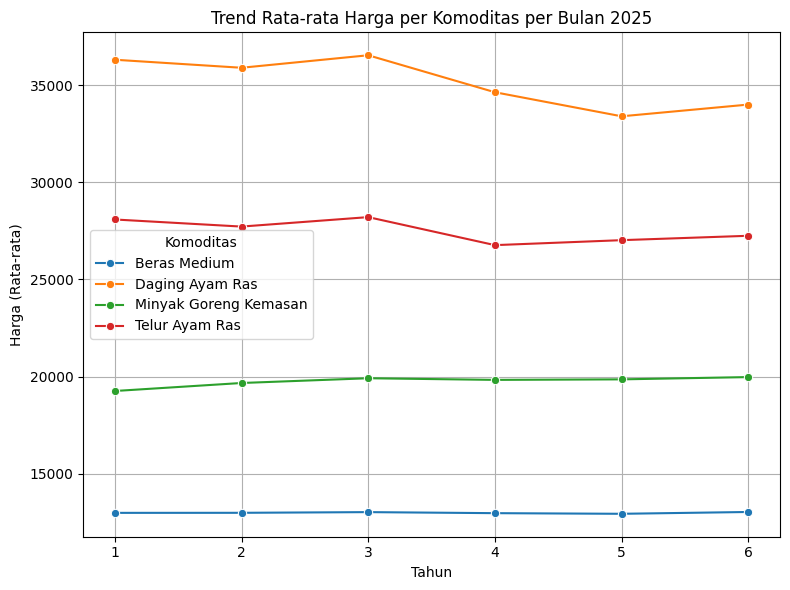

In [44]:
tren_per_month(2025)

Dari tren diatas:
1. Daging Ayam Ras : Harga relatif stabil tinggi di Q1 (Januari–Maret) sekitar Rp 36.000–Rp 37.000. Penurunan signifikan mulai April (Rp 34.700) hingga Mei (Rp 33.500), sedikit naik di Juni. Kemungkinan penyebab yaitu Permintaan tinggi di awal tahun menjelang Ramadhan dan Setelah Ramadhan dan Idul Fitri, permintaan menurun, sehingga harga turun.
2. Telur Ayam Ras : Tren harga stabil di kisaran Rp 27.000–Rp 28.200, Penurunan terjadi pada bulan April, kemudian perlahan naik kembali, Mirip pola dengan daging ayam, menandakan pengaruh musiman yang sama, konsumsi tinggi saat Ramadhan dan Lebaran, lalu menurun
3. Minyak Goreng Kemasan : Tren cenderung naik perlahan dari Januari (Rp 19.300) ke Juni (Rp 20.000) ini kemungkinan disebabkan Kenaikan harga minyak sawit mentah (CPO) sebagai bahan baku utama, peningkatan permintaan global, dan gangguan pasokan menjadi faktor pendorong utama
4. Beras Medium : Harga sangat stabil, sedikit naik dari Rp 12.800 ke Rp 13.000 kenaikan ini kemungkinan disebabkan perubahan musim panen dan fluktuasi permintaan dan penawaran